# Senario Generation (2025 Baseline vs Renewable Upside)

This notebook generates three senarios from 2025 actual data:

1. baseline: uses 2025 NET_LOAD actuals
2. senario_A: 1.5x solar, 1.0x wind
3. senario_B: 2.0x solar, 1.1x wind

Assumption: ERCOT.LOAD stays at 2025 actual values; only renewable generation is scaled.

In [26]:
# Kernel Management Cell
# Run this cell to install/upgrade packages and restart the kernel

# Step 1: Install/upgrade required packages
""" import sys
import subprocess

print("Installing required packages...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", 
    "--trusted-host", "pypi.org", 
    "--trusted-host", "files.pythonhosted.org",
    "--upgrade", "plotly", "kaleido"
])
print("Packages installed successfully!")
print("\n" + "="*60)
print("IMPORTANT: Now restart the kernel using your IDE:")
print("  - VS Code: Click 'Restart' button in notebook toolbar")
print("  - JupyterLab: Kernel menu -> Restart Kernel")
print("="*60)
 """
# Step 2: After restart, uncomment these lines to enable autoreload:
# %load_ext autoreload
# %autoreload 2
# print("Autoreload enabled - modules will be reloaded automatically")

' import sys\nimport subprocess\n\nprint("Installing required packages...")\nsubprocess.check_call([\n    sys.executable, "-m", "pip", "install", \n    "--trusted-host", "pypi.org", \n    "--trusted-host", "files.pythonhosted.org",\n    "--upgrade", "plotly", "kaleido"\n])\nprint("Packages installed successfully!")\nprint("\n" + "="*60)\nprint("IMPORTANT: Now restart the kernel using your IDE:")\nprint("  - VS Code: Click \'Restart\' button in notebook toolbar")\nprint("  - JupyterLab: Kernel menu -> Restart Kernel")\nprint("="*60)\n '

In [27]:
from pathlib import Path
import pandas as pd
from pathlib import Path
import sys

ROOT = Path('C:/Renewable-PowerGrid-Risk')
# Adds src to sys.path
src_path = ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
print(sys.path)


from metrics import compute_risk_metrics


ROOT = Path('C:/Renewable-PowerGrid-Risk')
SENARIO_DIR = ROOT / 'data' / 'senarios'
input_path = ROOT / 'data' / 'processed' / 'hourly_load_renewable_merged.csv'

df = pd.read_csv(input_path, parse_dates=['datetime'])
print(f'Loaded: {input_path}')
print(df.shape)

['C:\\Renewable-PowerGrid-Risk\\src', 'c:\\Renewable-PowerGrid-Risk\\notebooks', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\python39.zip', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\DLLs', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env', '', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages\\win32', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages\\win32\\lib', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages\\Pythonwin', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages\\setuptools\\_vendor']
Loaded: C:\Renewable-PowerGrid-Risk\data\processed\hourly_load_renewable_merged.csv
(26310, 23)


In [28]:
required_cols = ['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN', 'NET_LOAD']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')
 
df_2025 = df[df['datetime'].dt.year == 2025].copy()
if df_2025.empty:
    raise ValueError('No 2025 rows found in source data.')

print('2025 rows:', len(df_2025))
df_2025.head()  

2025 rows: 8762


,datetime,Date,ERCOT.LOAD,ERCOT.WIND.GEN,"Total Wind Installed, MW","Wind Output, % of Load","Wind Output, % of Installed",Wind 1-hr MW change,Wind 1-hr % change,ERCOT.PVGR.GEN,...,Solar 1-hr MW change,Solar 1-hr % change,Daytime Hour,Ramping Daytime Hour,hour,month,renewable,renewable_capacity,renewable_share,NET_LOAD
17547,2025-01-01 00:00:00,2025-01-01,44715.455903,13285.939850,39357,29.712187,33.757501,1481.889068,12.554072,0.703511,...,0.0,0.0,NaN,NaN,0,1,13286.643361,68150,0.297138,31428.812542
17548,2025-01-01 01:00:00,2025-01-01,44110.291011,14369.247057,39357,32.575725,36.510016,NaN,NaN,0.724839,...,NaN,NaN,False,False,1,1,14369.971896,68150,0.325774,29740.319115
17549,2025-01-01 02:00:00,2025-01-01,43795.576070,14888.718368,39357,33.995941,37.829912,519.471311,3.615160,0.743425,...,0.0,0.0,False,False,2,1,14889.461793,68150,0.339976,28906.114277
17550,2025-01-01 03:00:00,2025-01-01,43630.220156,15306.719255,39357,35.082838,38.891987,418.000887,2.807501,0.742429,...,0.0,0.0,False,False,3,1,15307.461684,68150,0.350845,28322.758472
17551,2025-01-01 04:00:00,2025-01-01,43519.323668,15025.925240,39357,34.527019,38.178533,-280.794015,-1.834449,0.752879,...,0.0,0.0,False,False,4,1,15026.678119,68150,0.345287,28492.645548


In [29]:
# Baseline: use actual 2025 NET_LOAD
baseline = df_2025[['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN', 'NET_LOAD']].copy()
baseline['scenario'] = 'baseline'

# Senario A: 1.5x solar, 1.0x wind
senario_a = df_2025[['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN']].copy()
senario_a['ERCOT.PVGR.GEN'] = senario_a['ERCOT.PVGR.GEN'] * 1.5
senario_a['ERCOT.WIND.GEN'] = senario_a['ERCOT.WIND.GEN'] * 1.0
senario_a['NET_LOAD'] = senario_a['ERCOT.LOAD'] - senario_a['ERCOT.PVGR.GEN'] - senario_a['ERCOT.WIND.GEN']
senario_a['scenario'] = 'senario_A'

# Senario B: 1.0x solar, 1.5x wind
senario_b = df_2025[['datetime', 'ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN']].copy()
senario_b['ERCOT.PVGR.GEN'] = senario_b['ERCOT.PVGR.GEN'] * 1.0
senario_b['ERCOT.WIND.GEN'] = senario_b['ERCOT.WIND.GEN'] * 1.5
senario_b['NET_LOAD'] = senario_b['ERCOT.LOAD'] - senario_b['ERCOT.PVGR.GEN'] - senario_b['ERCOT.WIND.GEN']
senario_b['scenario'] = 'senario_B'

scenario_all = pd.concat([baseline, senario_a, senario_b], ignore_index=True)
scenario_all = scenario_all.sort_values(['scenario', 'datetime']).reset_index(drop=True)

print(scenario_all['scenario'].value_counts())
scenario_all.head()

scenario
baseline     8762
senario_A    8762
senario_B    8762
Name: count, dtype: int64


,datetime,ERCOT.LOAD,ERCOT.PVGR.GEN,ERCOT.WIND.GEN,NET_LOAD,scenario
0,2025-01-01 00:00:00,44715.455903,0.703511,13285.939850,31428.812542,baseline
1,2025-01-01 01:00:00,44110.291011,0.724839,14369.247057,29740.319115,baseline
2,2025-01-01 02:00:00,43795.576070,0.743425,14888.718368,28906.114277,baseline
3,2025-01-01 03:00:00,43630.220156,0.742429,15306.719255,28322.758472,baseline
4,2025-01-01 04:00:00,43519.323668,0.752879,15025.925240,28492.645548,baseline


In [30]:
summary = scenario_all.groupby('scenario')[['ERCOT.LOAD', 'ERCOT.PVGR.GEN', 'ERCOT.WIND.GEN', 'NET_LOAD']].agg(['mean', 'max', 'min'])
summary.round(2)

ERCOT.LOAD                    ERCOT.PVGR.GEN                  \
                mean       max      min           mean       max   min   
scenario                                                                 
baseline    56436.17  83876.46  38617.9        7705.52  29503.09  0.02   
senario_A   56436.17  83876.46  38617.9       11558.28  44254.63  0.03   
senario_B   56436.17  83876.46  38617.9        7705.52  29503.09  0.02   

          ERCOT.WIND.GEN                    NET_LOAD                      
                    mean       max     min      mean       max       min  
scenario                                                                  
baseline        13119.36  28264.50  168.65  35611.29  69401.91  11492.38  
senario_A       13119.36  28264.50  168.65  31758.53  68928.82    789.54  
senario_B       19679.04  42396.75  252.98  29051.61  66714.45  -1103.00

In [31]:
out_all = SENARIO_DIR / 'senario_generation_2025_all.csv'
out_base = SENARIO_DIR / 'senario_generation_2025_baseline.csv'
out_a = SENARIO_DIR / 'senario_generation_2025_senario_A.csv'
out_b = SENARIO_DIR / 'senario_generation_2025_senario_B.csv'

scenario_all.to_csv(out_all, index=False)
baseline.to_csv(out_base, index=False)
senario_a.to_csv(out_a, index=False)
senario_b.to_csv(out_b, index=False)

print('Saved files:')
print(out_all)
print(out_base)
print(out_a)
print(out_b)

Saved files:
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_all.csv
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_baseline.csv
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_senario_A.csv
C:\Renewable-PowerGrid-Risk\data\senarios\senario_generation_2025_senario_B.csv


In [32]:
# 1. Define the range: from 1.0 (Base) to 2.0 (Scenario B) in 0.1 steps
multipliers_solar = [round(x * 0.01, 2) for x in range(100, 201)]
print(multipliers_solar)
#multipliers_wind = [round(x * 0.01, 2) for x in range(101, 121)]
multipliers_wind = [round(x * 0.01, 2) for x in range(100, 201)]
print(multipliers_wind)

[1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5, 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6, 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7, 1.71, 1.72, 1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8, 1.81, 1.82, 1.83, 1.84, 1.85, 1.86, 1.87, 1.88, 1.89, 1.9, 1.91, 1.92, 1.93, 1.94, 1.95, 1.96, 1.97, 1.98, 1.99, 2.0]
[1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5, 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6, 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.

In [33]:
df_4hr=df_2025[df_2025['hour'].isin([18,19,20,21])].copy()
sensitivity_results = []
for m in multipliers_solar:
    for w in multipliers_wind:
        # 2. Apply the multiplier to the solar data and wind data
        temp_solar = df_4hr['ERCOT.PVGR.GEN'] * m
        temp_wind = df_4hr['ERCOT.WIND.GEN'] * w
        # 3. Calculate the new Net Load (Load is constant)
        df_4hr['NET_LOAD_tmp'] = df_4hr['ERCOT.LOAD'] - temp_solar - temp_wind
        
        # 4. Calculate the Max Ramp (using his existing logic)
        #df["ramp_3h"] = df[net_load_col].diff(3)
        ## fix threshold for the based case P95 value 6033
        risk= compute_risk_metrics(df_4hr, net_load_col='NET_LOAD_tmp', fixed_threshold=16529.09)
        # 5. Store the results
        sensitivity_results.append({'multiplier_solar': m, 'multiplier_wind': w, 'risk': risk})
        # 'max_ramp': max_ramp_up
        #
        # max_ramp_up,max_ramp_down,threshold,tail_prob,conditional_tail,p99_ramp_1h,mean_abs_ramp_1h,\
        # std_abs_ramp_1h, max_ramp_3h,p95_ramp_3h, ramp_variance_1h,ramp_variance_3h = compute_risk_metrics(df_4hr, net_load_col='NET_LOAD_tmp')

# Convert to a DataFrame for easy plotting
sens_df = pd.DataFrame(sensitivity_results)

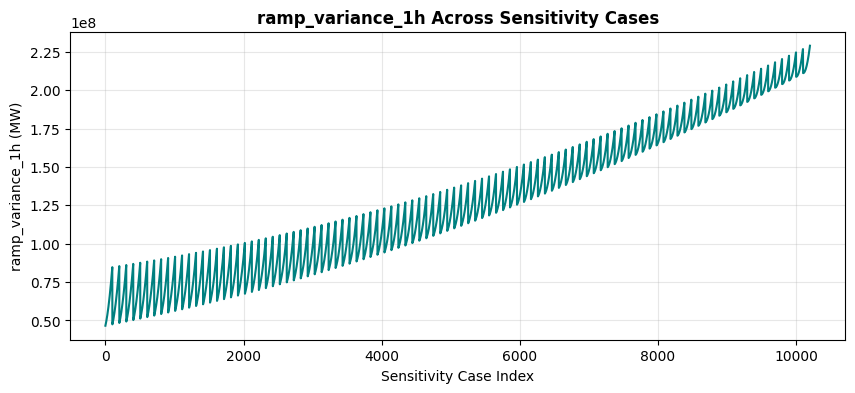

In [34]:

def plot_std_abs_ramp_1h(sens_df, var='std_abs_ramp_1h'):
    sens_df[var] = sens_df['risk'].apply(lambda risk: risk.get(var))

    ax = sens_df[var].plot(figsize=(10, 4), color='teal', linewidth=1.5)
    ax.set_title(f'{var} Across Sensitivity Cases', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sensitivity Case Index')
    ax.set_ylabel(f'{var} (MW)')
    ax.grid(alpha=0.3)

plot_std_abs_ramp_1h(sens_df, var='ramp_variance_1h')

In [39]:

def plot_3D(df, z_col):
    import numpy as np
    import plotly.express as px
    from pathlib import Path
    
    df[z_col] = df['risk'].apply(lambda risk: risk.get(z_col))
    z_values = df[z_col].astype(float)

    x_col = "multiplier_soler" if "multiplier_soler" in df.columns else "multiplier_solar"
    y_col= "multiplier_wind"   

    fig = px.scatter_3d(
        df,
        x=x_col,
        y= y_col,
        z=z_values,
        color=z_col,
        color_continuous_scale="Viridis",
        labels={
            x_col: "Solar Multiplier",
            "multiplier_wind": "Wind Multiplier",
            z_col: f"{z_col} (MW)",
        },
        title=f"Sensitivity of Sunset Upward-Ramp Volatility to Solar and Wind Scaling",
        hover_data={x_col: True, "multiplier_wind": True, z_col: ":.2f"},
    )

    tick_vals = np.linspace(z_values.min(), z_values.max(), 5)
    tick_vals_list = tick_vals.tolist()
    if abs(z_values.max()) >= 1_000_000:
        tick_labels = [f"{v / 1_000_000:.0f}MW" for v in tick_vals_list]
    else:
        tick_labels = [f"{v:.0f}MW" for v in tick_vals_list]

    fig.update_traces(marker=dict(size=4, opacity=0.85))
    fig.update_layout(
        coloraxis_colorbar=dict(
            title="Std(MW)",
            tickvals=tick_vals_list,
            ticktext=tick_labels,
        ),
        scene=dict(
            xaxis=dict(
                title="Solar Multiplier",
                range=[1.0, 2.0],
                tickmode="linear",
                tick0=1.0,
                dtick=0.2,
            ),
            yaxis=dict(
                title="Wind Multiplier",
                range=[1.0, 2.0],
                tickmode="linear",
                tick0=1.0,
                dtick=0.2,
            ),
            zaxis=dict(
                title="Standard deviation of positive 1-hour sunset ramps (MW)",
                tickvals=tick_vals_list,
                ticktext=tick_labels,
            ),
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        scene_camera=dict(eye=dict(x=1.6, y=1.6, z=1.1)),
        width=850,
        height=650,
    )
    fig.show()
    
    # Save as static image for GitHub
    figures_dir = ROOT / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    img_path = figures_dir / f"3d_{z_col}.png"
    html_path = figures_dir / f"3d_{z_col}.html"
    
    fig.write_image(str(img_path), width=850, height=650)
    fig.write_html(str(html_path))
    
    print(f"Saved: {img_path.relative_to(ROOT)}")
    print(f"Saved: {html_path.relative_to(ROOT)}")
    
    return fig

plot_3D(sens_df, z_col='std_abs_ramp_1h')


Saved: figures\3d_std_abs_ramp_1h.png
Saved: figures\3d_std_abs_ramp_1h.html


## Findings Summary
The 3D sensitivity analysis indicates that short-term ramping volatility increases systematically as renewable multipliers rise. Using the metric std_abs_ramp_1h (the standard deviation of absolute 1-hour net-load ramps), the lowest volatility occurs near the baseline case and the highest volatility occurs at the upper end of the solar and wind scenario space. This pattern shows that stronger renewable penetration, without additional balancing changes, is associated with larger variation in hour-to-hour net-load movement during the critical evening ramp period.

This result is expected from power-system physics and daily demand patterns. Net load is defined as demand minus renewable generation, so when daytime solar production is higher, net load is pushed lower during sunlight hours. Near sunset, solar output falls quickly, but customer demand often remains high as people return home, use cooling or heating, and increase appliance usage. Because the system must replace that lost solar energy over a short time, hour-to-hour ramps become steeper and less uniform, which raises std_abs_ramp_1h.

The response surface also indicates a stronger solar effect relative to wind for this metric. As the solar multiplier increases, volatility rises more steeply, consistent with the concentrated daytime profile of solar generation and its sharp evening decline. Wind expansion still contributes to variability, but with a more gradual gradient across the tested range because wind output is distributed more broadly across hours. In practical terms, the grid benefits from cleaner energy under higher renewable scenarios, but it also requires more flexibility resources (fast-ramping generation, storage, and demand response) to maintain reliability during sunset transitions.

In [36]:
plot_3D(sens_df, z_col='ramp_variance_3h')

Saved: figures\3d_ramp_variance_3h.png
Saved: figures\3d_ramp_variance_3h.html


In [37]:
# Tail-risk summary for the sensitivity grid
tail_df = sens_df.copy()
tail_df['tail_probability'] = tail_df['risk'].apply(lambda risk: risk.get('tail_probability'))
tail_df['conditional_tail'] = tail_df['risk'].apply(lambda risk: risk.get('conditional_tail'))
tail_df['threshold_P95'] = tail_df['risk'].apply(lambda risk: risk.get('threshold_P95'))
tail_df['p99_ramp_1h'] = tail_df['risk'].apply(lambda risk: risk.get('p99_ramp_1h'))

summary_stats = tail_df[['tail_probability', 'conditional_tail', 'threshold_P95', 'p99_ramp_1h']].agg(['min', 'mean', 'max']).round(2)
display(summary_stats)

peak_tail = tail_df.loc[tail_df['tail_probability'].idxmax(), ['multiplier_solar', 'multiplier_wind', 'tail_probability', 'conditional_tail']]
baseline_tail = tail_df.loc[(tail_df['multiplier_solar'] == 1.0) & (tail_df['multiplier_wind'] == 1.0), ['tail_probability', 'conditional_tail', 'threshold_P95', 'p99_ramp_1h']].iloc[0]

print('Baseline tail-risk metrics:')
print(baseline_tail.round(2))
print()
print('Peak tail-risk case:')
print({k: round(float(v), 2) if k in ['multiplier_solar', 'multiplier_wind', 'tail_probability', 'conditional_tail'] else v for k, v in peak_tail.to_dict().items()})

,tail_probability,conditional_tail,threshold_P95,p99_ramp_1h
min,0.03,20335.58,16529.09,21872.50
mean,0.13,23991.93,16529.09,33606.77
max,0.24,26806.49,16529.09,43906.39


Baseline tail-risk metrics:
tail_probability        0.03
conditional_tail    20559.53
threshold_P95       16529.09
p99_ramp_1h         21872.50
Name: 0, dtype: float64

Peak tail-risk case:
{'multiplier_solar': 2.0, 'multiplier_wind': 1.65, 'tail_probability': 0.24, 'conditional_tail': 25849.14}


## Tail-Risk Findings Summary
Tail-risk results show that the extreme end of the ramp distribution becomes progressively more important as renewable multipliers increase. Using the fixed 2025 threshold, the baseline case remains close to the reference tail-probability level, while the high-renewable cases move further into the upper tail and produce larger conditional tail expectations. This indicates that the most severe operating stress is not captured by average variability alone, but by the subset of hours where net load changes exceed the reference threshold by a wide margin.

The tail-risk surface is consistent with the physical structure of the problem: higher solar and wind scaling increases the chance that evening net load will move into the extreme-ramp region, especially during the sunset transition when solar output falls rapidly. In practical terms, the results show that renewable expansion can improve energy supply, but it also raises the likelihood of rare, high-consequence ramp events unless flexibility resources such as storage, fast-ramping generation, or demand response are added in parallel.